In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

print("pytorch:", torch.__version__)

pytorch: 2.12.1+cu130


In [2]:
df = pd.read_csv("loan_default_dataset.csv")
print(df.shape)
df.head()

(5000, 14)


,Age,Annual_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Employment_Years,Num_Credit_Lines,Debt_To_Income_Ratio,Num_Late_Payments,Has_Mortgage,Education,Loan_Purpose,Marital_Status,Loan_Default
0,60,98484,12490,36,388,12,4,0.24,2,1,Master,Education,Single,0
1,50,138747,29502,48,710,12,3,0.18,4,1,High School,Personal,Married,0
2,36,33026,40757,60,540,23,2,0.53,0,0,Bachelor,Business,Single,0
3,64,88309,46111,36,522,23,2,0.10,8,1,Bachelor,Home,Married,0
4,29,65927,88245,24,767,13,8,0.19,7,1,Master,Education,Single,0


In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_clean = df.copy()

for col in ['Education', 'Loan_Purpose', 'Marital_Status']:
    df_clean[col] = le.fit_transform(df_clean[col])

df_clean['Loan_To_Income'] = df_clean['Loan_Amount'] / df_clean['Annual_Income']
df_clean['Risk_Score'] = (df_clean['Num_Late_Payments'] * 2 +
                           df_clean['Debt_To_Income_Ratio'] * 10 -
                           df_clean['Credit_Score'] / 100)

X = df_clean.drop(columns=['Loan_Default']).values.astype(np.float32)
y = df_clean['Loan_Default'].values.astype(np.int64)

# normalize
X_mean = X.mean(axis=0)
X_std = X.std(axis=0) + 1e-8
X = (X - X_mean) / X_std

print("X:", X.shape)
print("y:", y.shape)

X: (5000, 15)
y: (5000,)


In [4]:
# train/val/test split  70/15/15
idx = np.random.permutation(len(X))
train_end = int(0.70 * len(X))
val_end   = int(0.85 * len(X))

X_train = torch.FloatTensor(X[idx[:train_end]])
y_train = torch.LongTensor(y[idx[:train_end]])

X_val   = torch.FloatTensor(X[idx[train_end:val_end]])
y_val   = torch.LongTensor(y[idx[train_end:val_end]])

X_test  = torch.FloatTensor(X[idx[val_end:]])
y_test  = torch.LongTensor(y[idx[val_end:]])

print("train:", X_train.shape)
print("val  :", X_val.shape)
print("test :", X_test.shape)

train: torch.Size([3500, 15])
val  : torch.Size([750, 15])
test : torch.Size([750, 15])


In [5]:
# wrapping tensors in TensorDataset then DataLoader

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val,   y_val)

# shuffle=True only for training
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)

print("train batches:", len(train_loader))
print("val batches  :", len(val_loader))
print("batch size   : 64")

train batches: 55
val batches  : 12
batch size   : 64


In [6]:
# same MLP from day 11

class LoanMLP(nn.Module):
    def __init__(self, input_dim):
        super(LoanMLP, self).__init__()
        self.fc1   = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.3)
        self.fc2   = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.2)
        self.fc3   = nn.Linear(32, 2)

    def forward(self, x):
        x = self.drop1(self.relu1(self.fc1(x)))
        x = self.drop2(self.relu2(self.fc2(x)))
        return self.fc3(x)

model = LoanMLP(X_train.shape[1])
print(model)

LoanMLP(
  (fc1): Linear(in_features=15, out_features=64, bias=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
)


In [7]:
# adam optimizer + crossentropy loss
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("optimizer: Adam lr=0.001")
print("loss: CrossEntropyLoss")

optimizer: Adam lr=0.001
loss: CrossEntropyLoss


In [8]:
# mini-batch training loop - 25 epochs

EPOCHS = 25
train_losses = []
val_losses   = []

for epoch in range(EPOCHS):

    # --- training ---
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    # --- validation (no gradients) ---
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            out      = model(X_batch)
            val_loss = criterion(out, y_batch)
            val_batch_losses.append(val_loss.item())

    val_loss_avg = np.mean(val_batch_losses)

    train_losses.append(train_loss)
    val_losses.append(val_loss_avg)

    print(f"epoch {epoch+1:02d}/25  train_loss: {train_loss:.4f}  val_loss: {val_loss_avg:.4f}")

print("\ntraining done!")

epoch 01/25  train_loss: 0.5386  val_loss: 0.4622
epoch 02/25  train_loss: 0.4970  val_loss: 0.4500


epoch 03/25  train_loss: 0.4892  val_loss: 0.4473
epoch 04/25  train_loss: 0.4908  val_loss: 0.4477


epoch 05/25  train_loss: 0.4853  val_loss: 0.4434
epoch 06/25  train_loss: 0.4876  val_loss: 0.4422


epoch 07/25  train_loss: 0.4858  val_loss: 0.4421
epoch 08/25  train_loss: 0.4806  val_loss: 0.4437


epoch 09/25  train_loss: 0.4818  val_loss: 0.4447
epoch 10/25  train_loss: 0.4773  val_loss: 0.4423


...

epoch 17/25  train_loss: 0.4759  val_loss: 0.4456
epoch 18/25  train_loss: 0.4774  val_loss: 0.4410


epoch 19/25  train_loss: 0.4764  val_loss: 0.4409
epoch 20/25  train_loss: 0.4720  val_loss: 0.4441


epoch 21/25  train_loss: 0.4708  val_loss: 0.4394
epoch 22/25  train_loss: 0.4759  val_loss: 0.4452


epoch 23/25  train_loss: 0.4700  val_loss: 0.4428
epoch 24/25  train_loss: 0.4710  val_loss: 0.4411


epoch 25/25  train_loss: 0.4703  val_loss: 0.4407

training done!


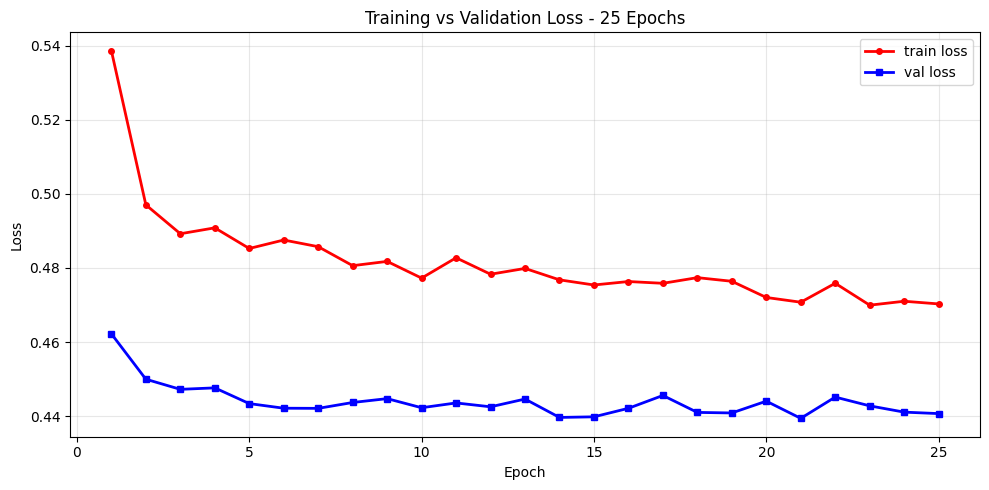

final train loss: 0.4703
final val loss  : 0.4407


In [9]:
# train vs val loss curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, 26), train_losses, label='train loss', color='red',   linewidth=2, marker='o', markersize=4)
plt.plot(range(1, 26), val_losses,   label='val loss',   color='blue',  linewidth=2, marker='s', markersize=4)
plt.title('Training vs Validation Loss - 25 Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('train_val_loss.png', dpi=150, bbox_inches='tight')
plt.show()

print("final train loss:", round(train_losses[-1], 4))
print("final val loss  :", round(val_losses[-1], 4))

In [10]:
# test set evaluation
model.eval()
with torch.no_grad():
    out = model(X_test)
    _, preds = torch.max(out, 1)
    acc = (preds == y_test).float().mean().item()

from sklearn.metrics import classification_report, f1_score
y_true = y_test.numpy()
y_pred = preds.numpy()

print(f"test accuracy : {acc*100:.2f}%")
print(f"f1 score      : {f1_score(y_true, y_pred):.4f}")
print()
print(classification_report(y_true, y_pred, target_names=['no default', 'default']))

test accuracy : 80.53%
f1 score      : 0.0000

              precision    recall  f1-score   support

  no default       0.81      1.00      0.89       605
     default       0.00      0.00      0.00       145

    accuracy                           0.81       750
   macro avg       0.40      0.50      0.45       750
weighted avg       0.65      0.81      0.72       750



In [11]:
# why adam > sgd
print("SGD: fixed learning rate for all parameters")
print("Adam: adaptive lr per parameter using:")
print("  mt = moving average of gradients")
print("  vt = moving average of squared gradients")
print("  update = alpha / (sqrt(vt) + eps) * mt")
print()
print("adam advantages:")
print("- different lr per parameter (good for sparse features)")
print("- momentum prevents getting stuck in saddle points")
print("- faster convergence than plain sgd")
print()
print("why mini-batches?")
print("- full dataset at once = RAM crash for large data")
print("- batch_size=64 means 64 samples loaded at a time")
print("- gradients updated more often = faster, stable learning")

SGD: fixed learning rate for all parameters
Adam: adaptive lr per parameter using:
  mt = moving average of gradients
  vt = moving average of squared gradients
  update = alpha / (sqrt(vt) + eps) * mt

adam advantages:
- different lr per parameter (good for sparse features)
- momentum prevents getting stuck in saddle points
- faster convergence than plain sgd

why mini-batches?
- full dataset at once = RAM crash for large data
- batch_size=64 means 64 samples loaded at a time
- gradients updated more often = faster, stable learning
